In [ ]:
# === auto-inserted: bev-solving src on path ===
import sys, pathlib
_root = pathlib.Path.cwd()
while _root != _root.parent and not (_root / 'src' / 'geometry.py').exists():
    _root = _root.parent
if str(_root) not in sys.path:
    sys.path.insert(0, str(_root))


# BEVDet 4-Camera Sanity Check

Этот ноутбук предназначен для **быстрого sanity check** `BEVDet`/`BEVDet-Occ` на нашем датасете без вмешательства в текущие обучения.

Что делает ноутбук:
- переиспользует cleaned pipeline и `test-matched` val split из `train_v4_dinov2_cleaned.ipynb`;
- собирает 6-камерный вход под `nuScenes/BEVDet` из наших 4 камер;
- зануляет отсутствующие rear views;
- даёт несколько mapping presets для фронтальной камеры;
- пытается загрузить официальный `BEVDet` repo + config + checkpoint;
- делает сначала **safe checks** на данных и shapes, затем **best-effort** `extract_img_feat`, и только потом пробует полный forward.

Ожидаемое использование на Datasphere:
1. скачать/склонить `BEVDet` в локальную папку;
2. скачать конкретный config и checkpoint;
3. прогнать ноутбук сверху вниз;
4. посмотреть, удаётся ли модели принять наши 4 камеры и выдать осмысленные фичи/предсказания.


## Что лучше скачать заранее

Минимум:
- репозиторий `BEVDet`;
- occupancy config, например `configs/bevdet_occ/bevdet-occ-r50-4d-stereo-384x704.py`;
- occupancy checkpoint под этот config, если найдёте;
- если occupancy checkpoint нет, можно начать хотя бы с detection checkpoint `bevdet-r50.pth` и проверить только backbone/BEV feature path.

Справка по источникам:
- официальный репозиторий `BEVDet`: https://github.com/HuangJunJie2017/BEVDet
- в `nuScenes` используются 6 камер: `CAM_FRONT_LEFT`, `CAM_FRONT`, `CAM_FRONT_RIGHT`, `CAM_BACK_LEFT`, `CAM_BACK`, `CAM_BACK_RIGHT`
- официальный `BEVDet` README перечисляет occupancy configs и результаты на `nuScenes`


In [1]:
import gc
import json
import math
import os
import random
import sys
import time
import importlib
from collections import Counter
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
from PIL import Image
from torch.utils.data import Dataset, DataLoader
from tqdm.auto import tqdm
import matplotlib.pyplot as plt

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device =', device)


device = cuda


In [2]:
DATA_TRAIN = Path('./autonomy_yandex_dataset_train/')
DATA_VAL = Path('./autonomy_yandex_dataset_val/')
DATA_TEST = Path('./autonomy_yandex_dataset_test/')

RUN_DIR = Path('./runs/bevdet_sanity_check')
RUN_DIR.mkdir(parents=True, exist_ok=True)
CACHE_DIR = RUN_DIR / 'preproc_cache'
CACHE_DIR.mkdir(parents=True, exist_ok=True)

# Заполните эти пути под свою Datasphere-сессию.
BEVDET_REPO = Path('./external/BEVDet')
BEVDET_CONFIG = BEVDET_REPO / 'configs/bevdet_occ/bevdet-occ-r50-4d-stereo-384x704.py'
BEVDET_CKPT = Path('./checkpoints/bevdet_occ_r50_4d_stereo_384x704.pth')

OUR_CAMERA_NAMES = [
    '/camera/inner/frontal/middle',
    '/camera/inner/frontal/far',
    '/side/left/forward',
    '/side/right/forward',
]
OUR_INTRINSICS_NAMES = [n + '/intrinsic_params' for n in OUR_CAMERA_NAMES]
OUR_CAR2CAM_NAMES = [n + '/car_to_cam' for n in OUR_CAMERA_NAMES]
GT_NAME = 'gt_occupancy_grid'

BEVDET_CAMERA_ORDER = [
    'CAM_FRONT_LEFT',
    'CAM_FRONT',
    'CAM_FRONT_RIGHT',
    'CAM_BACK_LEFT',
    'CAM_BACK',
    'CAM_BACK_RIGHT',
]

MAPPING_PRESETS = {
    'front_middle': {
        'CAM_FRONT_LEFT': '/side/left/forward',
        'CAM_FRONT': '/camera/inner/frontal/middle',
        'CAM_FRONT_RIGHT': '/side/right/forward',
        'CAM_BACK_LEFT': None,
        'CAM_BACK': None,
        'CAM_BACK_RIGHT': None,
    },
    'front_far': {
        'CAM_FRONT_LEFT': '/side/left/forward',
        'CAM_FRONT': '/camera/inner/frontal/far',
        'CAM_FRONT_RIGHT': '/side/right/forward',
        'CAM_BACK_LEFT': None,
        'CAM_BACK': None,
        'CAM_BACK_RIGHT': None,
    },
}

cfg = {
    'img_hw': (384, 704),
    'val_target_size': 200,
    'mae_dedup_thr': 0.02,
    'dedup_camera': '/camera/inner/frontal/middle',
    'batch_size': 1,
    'num_workers': 0,
    'bevdet_input_hw': (384, 704),
    'mapping_preset': 'front_middle',
    'normalize_mean': [123.675, 116.28, 103.53],
    'normalize_std': [58.395, 57.12, 57.375],
    'to_rgb': True,
}

print(json.dumps(cfg, indent=2))
print('BEVDET_REPO exists:', BEVDET_REPO.exists())
print('BEVDET_CONFIG exists:', BEVDET_CONFIG.exists())
print('BEVDET_CKPT exists:', BEVDET_CKPT.exists())


{
  "img_hw": [
    384,
    704
  ],
  "val_target_size": 200,
  "mae_dedup_thr": 0.02,
  "dedup_camera": "/camera/inner/frontal/middle",
  "batch_size": 1,
  "num_workers": 0,
  "bevdet_input_hw": [
    384,
    704
  ],
  "mapping_preset": "front_middle",
  "normalize_mean": [
    123.675,
    116.28,
    103.53
  ],
  "normalize_std": [
    58.395,
    57.12,
    57.375
  ],
  "to_rgb": true
}
BEVDET_REPO exists: False
BEVDET_CONFIG exists: False
BEVDET_CKPT exists: False


In [ ]:
from src.cleaning import clean_merged_info, compute_gt_stats, smart_deduplicate
from src.geometry import load_info_with_root
from src.splits import make_test_matched_split_target
from src.utils.training import cleanup_cuda

def resolve_path(row: pd.Series, key: str) -> Path:
    base = Path(row['__data_root'])
    p = Path(row[key])
    if p.is_absolute() and p.exists():
        return p
    if p.exists():
        return p
    if (base / p).exists():
        return base / p
    if (base.parent / p).exists():
        return base.parent / p
    return base / p

def grayscale_signature(image_path: Path, size: int = 32) -> np.ndarray:
    img = Image.open(image_path).convert('L').resize((size, size), Image.BILINEAR)
    arr = np.asarray(img, dtype=np.float32) / 255.0
    return arr


In [4]:
clean_info, dedup_report, clean_summary = clean_merged_info(
    DATA_TRAIN,
    DATA_VAL,
    CACHE_DIR,
    mae_thr=cfg['mae_dedup_thr'],
    dedup_camera=cfg['dedup_camera'],
)
print(json.dumps(clean_summary, indent=2))
if len(dedup_report):
    display(dedup_report.head(10))

test_info = load_info_with_root(DATA_TEST, 'test')
train_idx, val_idx = make_test_matched_split_target(
    clean_info,
    test_info,
    target_val_size=cfg['val_target_size'],
    seed=SEED,
)
train_info = clean_info.iloc[train_idx].reset_index(drop=True).copy()
val_info = clean_info.iloc[val_idx].reset_index(drop=True).copy()

print('clean total:', len(clean_info))
print('train size:', len(train_info))
print('val size:', len(val_info))
print('val rover top counts:')
display(val_info['rover'].value_counts().head(15).to_frame('count'))


Smart dedup groups: 100%|██████████| 1473/1473 [02:19<00:00, 10.57it/s]


{
  "before": 5000,
  "after_empty_filter": 4883,
  "removed_empty": 117,
  "after_dedup": 4493,
  "removed_by_dedup": 390,
  "dedup_groups": 390
}


,rover,ride_date,message_ts,winner_message_ts,cluster_id,pos_count,winner_pos_count
0,alvaro,2025-03-10,1741637402900213000,1741637402300079000,0,4705,4753
1,baland,2021-12-29,1640773608599742000,1640773608999716000,1,2833,2907
2,baland,2022-06-20,1655742609000082000,1655742609500077000,1,1911,2012
3,baland,2022-06-20,1655742608500063000,1655742609500077000,1,1819,2012
4,baland,2022-06-20,1655742615000062000,1655742615500069000,2,4282,4465
5,baland,2022-06-20,1655742613500076000,1655742615500069000,2,3624,4465
6,baland,2022-06-20,1655742613000093000,1655742615500069000,2,3366,4465
7,baland,2022-06-20,1655742612500098000,1655742615500069000,2,3115,4465
8,baland,2025-03-30,1743325409699969000,1743325410300004000,0,467,501
9,balcel,2022-07-21,1658386838199994000,1658386844899987000,2,970,1506


clean total: 4493
train size: 4273
val size: 220
val rover top counts:


,count
orvy,38
shelly,29
lerita,20
greben,13
soan,13
natelio,10
benzon,6
greton,5
ward,5
targi,5


In [5]:
def compute_resize_post_transform(src_hw, dst_hw):
    src_h, src_w = src_hw
    dst_h, dst_w = dst_hw
    sx = float(dst_w) / float(src_w)
    sy = float(dst_h) / float(src_h)
    post_rot = np.eye(3, dtype=np.float32)
    post_rot[0, 0] = sx
    post_rot[1, 1] = sy
    post_tran = np.zeros(3, dtype=np.float32)
    return post_rot, post_tran, sx, sy


def resize_intrinsics(K: np.ndarray, sx: float, sy: float) -> np.ndarray:
    K2 = K.copy().astype(np.float32)
    K2[0, 0] *= sx
    K2[1, 1] *= sy
    K2[0, 2] *= sx
    K2[1, 2] *= sy
    return K2


def normalize_image_for_bevdet(img: np.ndarray, mean, std):
    img = img.astype(np.float32)
    mean = np.asarray(mean, dtype=np.float32).reshape(1, 1, 3)
    std = np.asarray(std, dtype=np.float32).reshape(1, 1, 3)
    img = (img - mean) / std
    return img


class BEVDetSanityDataset(Dataset):
    def __init__(self, info_df: pd.DataFrame, mode: str = 'val',
                 bevdet_input_hw=(384, 704),
                 mapping_preset='front_middle',
                 normalize_mean=(123.675, 116.28, 103.53),
                 normalize_std=(58.395, 57.12, 57.375)):
        self.info = info_df.reset_index(drop=True).copy()
        self.mode = mode
        self.input_hw = tuple(bevdet_input_hw)
        self.mapping_name = mapping_preset
        self.mapping = MAPPING_PRESETS[mapping_preset]
        self.normalize_mean = normalize_mean
        self.normalize_std = normalize_std

    def __len__(self):
        return len(self.info)

    def _load_our_views(self, row):
        out = {}
        for cam_name, intr_name, c2c_name in zip(OUR_CAMERA_NAMES, OUR_INTRINSICS_NAMES, OUR_CAR2CAM_NAMES):
            img = Image.open(resolve_path(row, cam_name)).convert('RGB')
            src_w, src_h = img.size
            post_rot, post_tran, sx, sy = compute_resize_post_transform((src_h, src_w), self.input_hw)
            img_resized = img.resize((self.input_hw[1], self.input_hw[0]), Image.BILINEAR)
            img_np = np.asarray(img_resized, dtype=np.float32)
            img_np = normalize_image_for_bevdet(img_np, self.normalize_mean, self.normalize_std)
            img_chw = np.transpose(img_np, (2, 0, 1))

            K = np.load(resolve_path(row, intr_name)).astype(np.float32)
            K = resize_intrinsics(K, sx, sy)
            ego_to_cam = np.load(resolve_path(row, c2c_name)).astype(np.float32)
            cam_to_ego = np.linalg.inv(ego_to_cam).astype(np.float32)

            out[cam_name] = {
                'image': img_chw,
                'intrin': K,
                'sensor2ego': cam_to_ego,
                'post_rot': post_rot,
                'post_tran': post_tran,
            }
        return out

    def __getitem__(self, idx):
        row = self.info.iloc[idx]
        our_views = self._load_our_views(row)

        front_source = self.mapping['CAM_FRONT']
        fallback = our_views[front_source]

        imgs = []
        sensor2egos = []
        ego2globals = []
        intrins = []
        post_rots = []
        post_trans = []
        source_names = []

        for bevdet_cam in BEVDET_CAMERA_ORDER:
            source_name = self.mapping[bevdet_cam]
            if source_name is None:
                source = fallback
                img_arr = np.zeros_like(source['image'], dtype=np.float32)
                sensor2ego = source['sensor2ego']
                intrin = source['intrin']
                post_rot = source['post_rot']
                post_tran = source['post_tran']
                source_names.append('__zero__')
            else:
                source = our_views[source_name]
                img_arr = source['image']
                sensor2ego = source['sensor2ego']
                intrin = source['intrin']
                post_rot = source['post_rot']
                post_tran = source['post_tran']
                source_names.append(source_name)

            imgs.append(torch.tensor(img_arr, dtype=torch.float32))
            sensor2egos.append(torch.tensor(sensor2ego, dtype=torch.float32))
            ego2globals.append(torch.eye(4, dtype=torch.float32))
            intrins.append(torch.tensor(intrin, dtype=torch.float32))
            post_rots.append(torch.tensor(post_rot, dtype=torch.float32))
            post_trans.append(torch.tensor(post_tran, dtype=torch.float32))

        sample = {
            'images_6': torch.stack(imgs, dim=0),
            'sensor2egos_6': torch.stack(sensor2egos, dim=0),
            'ego2globals_6': torch.stack(ego2globals, dim=0),
            'intrins_6': torch.stack(intrins, dim=0),
            'post_rots_6': torch.stack(post_rots, dim=0),
            'post_trans_6': torch.stack(post_trans, dim=0),
            'bda': torch.eye(4, dtype=torch.float32),
            'source_names': source_names,
            'info_idx': torch.tensor(idx, dtype=torch.long),
            'rover': row.get('rover', ''),
            'ride_date': row.get('ride_date', ''),
            'message_ts': row.get('message_ts', ''),
            'mapping_name': self.mapping_name,
        }

        if self.mode != 'test':
            gt = np.load(resolve_path(row, GT_NAME)).squeeze().astype(np.uint8)
            sample['gt_hard'] = torch.tensor(gt, dtype=torch.uint8)
        return sample


def build_img_inputs_from_batch(batch):
    return (
        batch['images_6'].to(device),
        batch['sensor2egos_6'].to(device),
        batch['ego2globals_6'].to(device),
        batch['intrins_6'].to(device),
        batch['post_rots_6'].to(device),
        batch['post_trans_6'].to(device),
        batch['bda'].to(device),
    )


def build_minimal_img_metas(batch):
    metas = []
    bs = batch['images_6'].shape[0]
    for i in range(bs):
        metas.append({
            'sample_idx': int(batch['info_idx'][i].item()),
            'ori_shape': [(900, 1600, 3)] * len(BEVDET_CAMERA_ORDER),
            'img_shape': [(cfg['bevdet_input_hw'][0], cfg['bevdet_input_hw'][1], 3)] * len(BEVDET_CAMERA_ORDER),
            'pad_shape': [(cfg['bevdet_input_hw'][0], cfg['bevdet_input_hw'][1], 3)] * len(BEVDET_CAMERA_ORDER),
            'scale_factor': 1.0,
            'box_mode_3d': None,
            'box_type_3d': None,
            'scene_token': 'custom_yandex_scene',
            'can_bus': np.zeros(18, dtype=np.float32),
            'flip': False,
            'pcd_horizontal_flip': False,
            'pcd_vertical_flip': False,
        })
    return metas


In [6]:
ds_val = BEVDetSanityDataset(
    val_info,
    mode='val',
    bevdet_input_hw=cfg['bevdet_input_hw'],
    mapping_preset=cfg['mapping_preset'],
    normalize_mean=cfg['normalize_mean'],
    normalize_std=cfg['normalize_std'],
)
loader_val = DataLoader(
    ds_val,
    batch_size=cfg['batch_size'],
    shuffle=False,
    num_workers=cfg['num_workers'],
    pin_memory=(device.type == 'cuda'),
)
print('val dataset size:', len(ds_val))
print('loader batch_size:', loader_val.batch_size)


val dataset size: 220
loader batch_size: 1


In [7]:
sample = ds_val[0]
print('mapping_name:', sample['mapping_name'])
print('source_names:', sample['source_names'])
print('images_6:', tuple(sample['images_6'].shape), sample['images_6'].dtype)
print('sensor2egos_6:', tuple(sample['sensor2egos_6'].shape))
print('intrins_6:', tuple(sample['intrins_6'].shape))
print('post_rots_6:', tuple(sample['post_rots_6'].shape))
print('post_trans_6:', tuple(sample['post_trans_6'].shape))
print('gt_hard:', tuple(sample['gt_hard'].shape), sample['gt_hard'].dtype)


mapping_name: front_middle
source_names: ['/side/left/forward', '/camera/inner/frontal/middle', '/side/right/forward', '__zero__', '__zero__', '__zero__']
images_6: (6, 3, 384, 704) torch.float32
sensor2egos_6: (6, 4, 4)
intrins_6: (6, 3, 4)
post_rots_6: (6, 3, 3)
post_trans_6: (6, 3)
gt_hard: (188, 126) torch.uint8


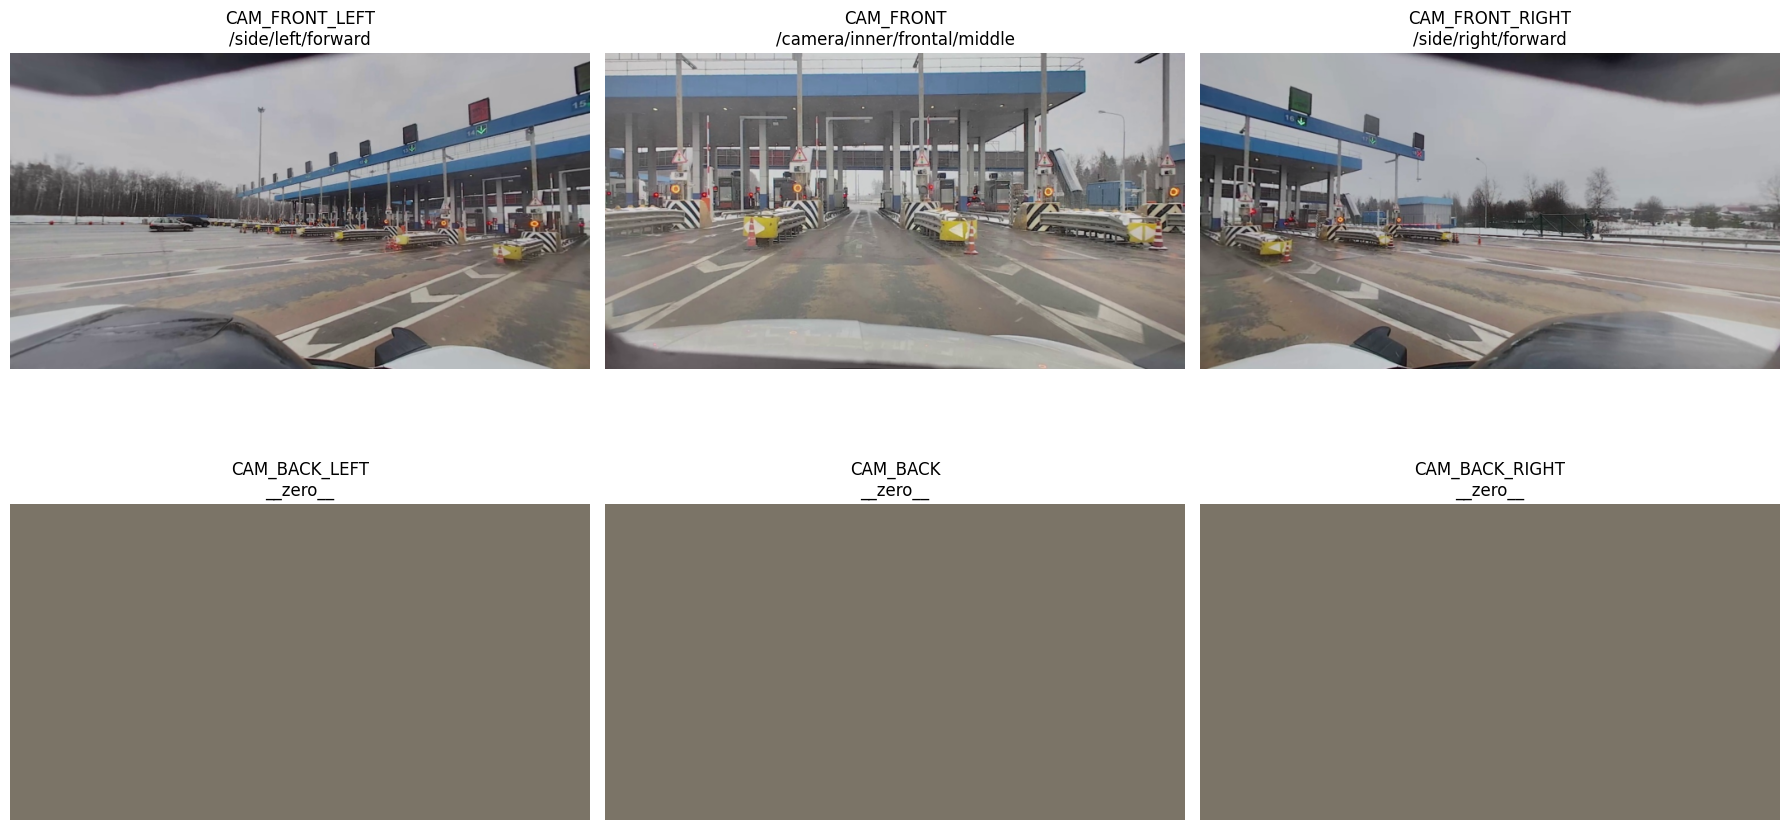

In [8]:
def denorm_bevdet_image(img_chw, mean, std):
    mean = np.asarray(mean, dtype=np.float32).reshape(3, 1, 1)
    std = np.asarray(std, dtype=np.float32).reshape(3, 1, 1)
    img = img_chw * std + mean
    img = np.transpose(img, (1, 2, 0))
    img = np.clip(img, 0, 255).astype(np.uint8)
    return img

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
for i, cam_name in enumerate(BEVDET_CAMERA_ORDER):
    ax = axes.flat[i]
    img = denorm_bevdet_image(sample['images_6'][i].numpy(), cfg['normalize_mean'], cfg['normalize_std'])
    ax.imshow(img)
    ax.set_title(f'{cam_name}\n{sample["source_names"][i]}')
    ax.axis('off')
plt.tight_layout()
plt.show()


## Опционально: установить/подготовить BEVDet

Если на Datasphere репозиторий ещё не готов, можно выполнить что-то в таком духе:

```bash
!git clone https://github.com/HuangJunJie2017/BEVDet.git external/BEVDet
!cd external/BEVDet && pip install -v -e .
```

Если occupancy checkpoint нет, всё равно имеет смысл сначала проверить хотя бы `extract_img_feat` на detection checkpoint.


In [9]:
!git clone https://github.com/HuangJunJie2017/BEVDet.git external/BEVDet

Cloning into 'external/BEVDet'...
Updating files: 100% (847/847), done.


In [10]:
!cd external/BEVDet && pip install -v -e .

Using pip 26.0.1 from /kernel/lib/python3.10/site-packages/pip (python 3.10)
Defaulting to user installation because normal site-packages is not writeable
Obtaining file:///home/jupyter/project/external/BEVDet
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Checking if build backend supports build_editable: started
  Checking if build backend supports build_editable: finished with status 'done'
  Getting requirements to build editable: started
  Getting requirements to build editable: finished with status 'error'


  Running command installing build dependencies
  Using pip 26.0.1 from /kernel/lib/python3.10/site-packages/pip (python 3.10)
    Obtaining dependency information for setuptools>=40.8.0 from https://files.pythonhosted.org/packages/9d/76/f789f7a86709c6b087c5a2f52f911838cad707cc613162401badc665acfe/setuptools-82.0.1-py3-none-any.whl.metadata
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 3.3 MB/s  0:00:00
  Running command Checking if build backend supports build_editable
  Running command Getting requirements to build editable
  Traceback (most recent call last):
    File "/kernel/lib/python3.10/site-packages/pip/_vendor/pyproject_hooks/_in_process/_in_process.py", line 389, in <module>
      main()
    File "/kernel/lib/python3.10/site-packages/pip/_vendor/pyproject_hooks/_in_process/_in_process.py", line 373, in main
      json_out["return_val"] = hook(**hook_input["kwargs"])
    File "/kernel/lib/python3.10/site-packages/pip/_vendor/pyproject_hooks/_in_process/_in_process.

Exception: Process exited with code 1

In [11]:
def import_bevdet_plugin(cfg_obj):
    plugin = getattr(cfg_obj, 'plugin', False)
    plugin_dir = getattr(cfg_obj, 'plugin_dir', None)
    if not plugin or not plugin_dir:
        return
    module_path = plugin_dir.replace('/', '.').replace('\\', '.')
    if module_path.endswith('.'):
        module_path = module_path[:-1]
    if str(BEVDET_REPO.resolve()) not in sys.path:
        sys.path.insert(0, str(BEVDET_REPO.resolve()))
    importlib.import_module(module_path)


def recursive_strip_pretrained(obj):
    if isinstance(obj, dict):
        if 'pretrained' in obj:
            obj['pretrained'] = None
        if 'init_cfg' in obj and isinstance(obj['init_cfg'], dict) and obj['init_cfg'].get('type') == 'Pretrained':
            obj['init_cfg'] = None
        for v in obj.values():
            recursive_strip_pretrained(v)
    elif isinstance(obj, list):
        for v in obj:
            recursive_strip_pretrained(v)


def load_bevdet_model(config_path: Path, checkpoint_path: Path | None, device: torch.device):
    if str(BEVDET_REPO.resolve()) not in sys.path:
        sys.path.insert(0, str(BEVDET_REPO.resolve()))

    try:
        from mmengine import Config
    except Exception:
        from mmcv import Config

    cfg_obj = Config.fromfile(str(config_path))
    import_bevdet_plugin(cfg_obj)

    model_cfg = cfg_obj.model.to_dict() if hasattr(cfg_obj.model, 'to_dict') else dict(cfg_obj.model)
    recursive_strip_pretrained(model_cfg)
    if 'train_cfg' in model_cfg:
        model_cfg['train_cfg'] = None

    model = None
    build_errs = []
    try:
        from mmdet3d.models import build_model
        model = build_model(model_cfg, test_cfg=cfg_obj.get('test_cfg'))
    except Exception as e:
        build_errs.append(f'build_model failed: {repr(e)}')

    if model is None:
        try:
            from mmdet3d.registry import MODELS
            model = MODELS.build(model_cfg)
        except Exception as e:
            build_errs.append(f'MODELS.build failed: {repr(e)}')

    if model is None:
        raise RuntimeError('Could not build model. Errors:\n' + '\n'.join(build_errs))

    if checkpoint_path is not None and Path(checkpoint_path).exists():
        load_errs = []
        loaded = False
        try:
            from mmengine.runner import load_checkpoint
            load_checkpoint(model, str(checkpoint_path), map_location='cpu', strict=False)
            loaded = True
        except Exception as e:
            load_errs.append(f'mmengine load_checkpoint failed: {repr(e)}')
        if not loaded:
            try:
                from mmcv.runner import load_checkpoint
                load_checkpoint(model, str(checkpoint_path), map_location='cpu', strict=False)
                loaded = True
            except Exception as e:
                load_errs.append(f'mmcv load_checkpoint failed: {repr(e)}')
        if not loaded:
            raise RuntimeError('Could not load checkpoint. Errors:\n' + '\n'.join(load_errs))

    model = model.to(device)
    model.eval()
    return model, cfg_obj


In [14]:
BEVDET_REPO = Path('./external/BEVDet')

candidate_configs = [
    BEVDET_REPO / 'configs/bevdet_occ/bevdet-occ-r50-4d-stereo-24e_384704.py',
    BEVDET_REPO / 'configs/bevdet_occ/bevdet-occ-r50-4d-stereo-24e.py',
    BEVDET_REPO / 'configs/bevdet_occ/bevdet-occ-r50-4dlongterm-stereo-24e_384704.py',
    BEVDET_REPO / 'configs/bevdet/bevdet-r50-4d-stereo-cbgs.py',
    BEVDET_REPO / 'configs/bevdet/bevdet-r50.py',
]

BEVDET_CONFIG = None
for p in candidate_configs:
    if p.exists():
        BEVDET_CONFIG = p
        break

print('selected config:', BEVDET_CONFIG)
assert BEVDET_CONFIG is not None, 'No BEVDet config found'


selected config: external/BEVDet/configs/bevdet_occ/bevdet-occ-r50-4d-stereo-24e_384704.py


In [19]:
import torch
print(torch.__version__)
print(torch.version.cuda)


2.0.1+cu118
11.8


In [18]:
!pip install mmcv

Defaulting to user installation because normal site-packages is not writeable
  Using cached mmcv-2.2.0.tar.gz (479 kB)
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'error'


  error: subprocess-exited-with-error
  
  × Getting requirements to build wheel did not run successfully.
  │ exit code: 1
  ╰─> [17 lines of output]
      Traceback (most recent call last):
        File "/kernel/lib/python3.10/site-packages/pip/_vendor/pyproject_hooks/_in_process/_in_process.py", line 389, in <module>
          main()
        File "/kernel/lib/python3.10/site-packages/pip/_vendor/pyproject_hooks/_in_process/_in_process.py", line 373, in main
          json_out["return_val"] = hook(**hook_input["kwargs"])
        File "/kernel/lib/python3.10/site-packages/pip/_vendor/pyproject_hooks/_in_process/_in_process.py", line 143, in get_requires_for_build_wheel
          return hook(config_settings)
        File "/tmp/pip-build-env-iwa5539z/overlay/local/lib/python3.10/dist-packages/setuptools/build_meta.py", line 333, in get_requires_for_build_wheel
          return self._get_build_requires(config_settings, requirements=[])
        File "/tmp/pip-build-env-iwa5539z/overlay/lo

Exception: Process exited with code 1

In [15]:
assert BEVDET_REPO.exists(), f'Missing repo: {BEVDET_REPO}'
assert BEVDET_CONFIG.exists(), f'Missing config: {BEVDET_CONFIG}'
if not BEVDET_CKPT.exists():
    print('Checkpoint not found yet. You can still run some config/model build checks, but checkpoint load will fail.')

cleanup_cuda()
try:
    bevdet_model, bevdet_cfg = load_bevdet_model(
        BEVDET_CONFIG,
        BEVDET_CKPT if BEVDET_CKPT.exists() else None,
        device,
    )
    print('model class:', bevdet_model.__class__.__name__)
    print('model loaded successfully')
except Exception as e:
    print('MODEL LOAD FAILED:')
    print(type(e).__name__, str(e))
    raise


Checkpoint not found yet. You can still run some config/model build checks, but checkpoint load will fail.
MODEL LOAD FAILED:
ModuleNotFoundError No module named 'mmcv'


ModuleNotFoundError: No module named 'mmcv'

In [ ]:
import inspect

print('has extract_img_feat:', hasattr(bevdet_model, 'extract_img_feat'))
print('has extract_feat:', hasattr(bevdet_model, 'extract_feat'))
print('has simple_test:', hasattr(bevdet_model, 'simple_test'))
print('has forward_test:', hasattr(bevdet_model, 'forward_test'))

if hasattr(bevdet_model, 'extract_img_feat'):
    try:
        print('extract_img_feat signature:', inspect.signature(bevdet_model.extract_img_feat))
    except Exception:
        print('could not inspect extract_img_feat signature')
if hasattr(bevdet_model, 'forward'):
    try:
        print('forward signature:', inspect.signature(bevdet_model.forward))
    except Exception:
        print('could not inspect forward signature')


In [ ]:
batch = next(iter(loader_val))
img_inputs = build_img_inputs_from_batch(batch)
img_metas = build_minimal_img_metas(batch)

for i, x in enumerate(img_inputs):
    if torch.is_tensor(x):
        print(i, tuple(x.shape), x.dtype, x.device)
    else:
        print(i, type(x))
print('num img_metas:', len(img_metas))
print('first meta keys:', sorted(img_metas[0].keys()))


In [ ]:
cleanup_cuda()

@torch.no_grad()
def try_extract_img_feat(model, img_inputs, img_metas):
    errs = []
    trials = [
        lambda: model.extract_img_feat(img_inputs, img_metas=img_metas),
        lambda: model.extract_img_feat(img=img_inputs, img_metas=img_metas),
        lambda: model.extract_feat(points=None, img=img_inputs, img_metas=img_metas),
        lambda: model.extract_feat(None, img=img_inputs, img_metas=img_metas),
    ]
    for fn in trials:
        try:
            out = fn()
            return out, None
        except Exception as e:
            errs.append(repr(e))
    return None, errs

feat_out, feat_errs = try_extract_img_feat(bevdet_model, img_inputs, img_metas)
if feat_out is None:
    print('extract_img_feat failed in all fallback paths:')
    for e in feat_errs:
        print('  ', e)
else:
    print('extract_img_feat succeeded')
    if isinstance(feat_out, (list, tuple)):
        for i, obj in enumerate(feat_out):
            if torch.is_tensor(obj):
                print(f'feat_out[{i}] ->', tuple(obj.shape), obj.dtype)
            elif isinstance(obj, (list, tuple)):
                print(f'feat_out[{i}] -> nested len={len(obj)}')
                for j, y in enumerate(obj):
                    if torch.is_tensor(y):
                        print(f'  nested[{j}]', tuple(y.shape), y.dtype)
            else:
                print(f'feat_out[{i}] ->', type(obj))
    elif torch.is_tensor(feat_out):
        print('feat_out ->', tuple(feat_out.shape), feat_out.dtype)
    else:
        print(type(feat_out))


In [ ]:
cleanup_cuda()

@torch.no_grad()
def try_full_forward(model, img_inputs, img_metas):
    errs = []
    trials = [
        lambda: model(return_loss=False, rescale=True, img_inputs=img_inputs, img_metas=img_metas),
        lambda: model(return_loss=False, img_inputs=img_inputs, img_metas=img_metas),
        lambda: model.forward_test(img=img_inputs, img_metas=img_metas),
        lambda: model.forward_test(img_inputs, img_metas),
        lambda: model.simple_test(points=None, img_metas=img_metas, img=img_inputs),
    ]
    for fn in trials:
        try:
            out = fn()
            return out, None
        except Exception as e:
            errs.append(repr(e))
    return None, errs

full_out, full_errs = try_full_forward(bevdet_model, img_inputs, img_metas)
if full_out is None:
    print('Full forward failed in all fallback paths:')
    for e in full_errs:
        print('  ', e)
else:
    print('Full forward succeeded')
    print(type(full_out))
    if isinstance(full_out, (list, tuple)):
        print('len =', len(full_out))
        for i, obj in enumerate(full_out[:5]):
            if torch.is_tensor(obj):
                print(i, tuple(obj.shape), obj.dtype)
            else:
                print(i, type(obj))
    elif isinstance(full_out, dict):
        print('keys =', list(full_out.keys())[:20])


## Как интерпретировать результат

Хороший исход sanity check:
- модель и checkpoint загружаются;
- `extract_img_feat` проходит;
- shapes разумные;
- `full forward` либо сразу проходит, либо падает уже на узкой части occupancy head, а не на image/view-transformer path.

Если `extract_img_feat` уже падает:
- значит либо API версии `BEVDet`/`mmdet3d` отличается,
- либо наш `img_inputs` ещё не совпал с их ожиданием,
- либо occupancy config требует дополнительных `img_metas`/temporal полей.

Если `extract_img_feat` проходит, а `full forward` нет:
- это уже хороший знак,
- и тогда следующим шагом проще донастроить именно inference interface, а не весь data path.
